# ZenAssist — analyse exploratoire et préparation des données

**Projet** : automatiser la catégorisation des réclamations clients de ZenAssist.
**Objectif global** : comparer une approche **LLM** et une approche **Machine Learning
classique** sur la même tâche, puis recommander l'une des deux au client.

**Ce notebook couvre l'étape 1** : comprendre les données, les nettoyer, définir un
découpage train/test défendable et arrêter les métriques de comparaison. Ni le LLM ni
les modèles ML n'y sont implémentés — c'est délibéré : les deux approches doivent être
mesurées sur des données et avec un code strictement identiques, sinon la comparaison
finale ne vaut rien.

---

## Comment lire ce notebook

Toute la logique vit dans `src/` : le notebook **importe** et **commente**, il ne
réimplémente rien. C'est une contrainte de conception, pas de style — le pipeline de
préparation doit être rejouable en une commande (`python -m src.data_prep`) sans passer
par un notebook, et l'étape 2 comme l'étape 3 réutiliseront exactement le même code de
mesure.

| Module | Rôle |
|---|---|
| `src/config.py` | chemins, constantes, référentiel d'étiquettes — **aucune valeur en dur ailleurs** |
| `src/data_prep.py` | chargement, nettoyage, découpage |
| `src/metrics.py` | métriques partagées par les étapes 2 et 3, **figé** une fois validé |

Trois rapports détaillés accompagnent ce notebook et sont référencés au fil des
sections : [`reports/diagnostic.md`](../reports/diagnostic.md),
[`reports/h1_sampling_simulation.md`](../reports/h1_sampling_simulation.md),
[`reports/limites.md`](../reports/limites.md).

> ⏱️ **Temps d'exécution** : environ 2 minutes au total. Deux cellules sont
> sensiblement plus lentes que les autres et sont signalées à l'endroit où elles
> apparaissent (chargement du fichier brut, puis nettoyage).

## 0. Mise en place

On remonte l'arborescence jusqu'à la racine du projet pour que `from src import ...`
fonctionne quel que soit le répertoire depuis lequel Jupyter a été lancé.

In [1]:
import sys
from pathlib import Path

# Remonte jusqu'a la racine du projet (le repertoire qui contient src/config.py).
RACINE = Path.cwd()
while not (RACINE / "src" / "config.py").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config as cfg
from src import data_prep as dp
from src import metrics as mt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)

# On n'affiche que le NOM du repertoire racine, jamais son chemin absolu : un
# .ipynb conserve ses sorties, et ce fichier est remis au client.
print("racine du projet :", RACINE.name + "/")
print("fichier brut     :", cfg.RAW_FILE.relative_to(RACINE),
      # Mo decimaux (10^6), unite utilisee partout dans le projet.
      f"({cfg.RAW_FILE.stat().st_size / 1e6:.0f} Mo)")
print("seed             :", cfg.RANDOM_SEED, "| test_size :", cfg.TEST_SIZE)

racine du projet : zenassist-classification/
fichier brut     : data/raw/dataset.csv (639 Mo)
seed             : 42 | test_size : 0.2


In [2]:
# --- charte graphique commune a toutes les figures du projet ----------------
# Palette validee (contraste et distinction pour les daltonismes courants).
SURFACE, ENCRE, ENCRE2, ATTENUE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRILLE, AXE = "#e1e0d9", "#c3c2b7"
BLEU, ORANGE = "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "savefig.bbox": "tight", "savefig.dpi": 150,
    "axes.edgecolor": AXE, "axes.linewidth": 0.8, "axes.labelcolor": ENCRE2,
    "text.color": ENCRE, "xtick.color": ATTENUE, "ytick.color": ATTENUE,
    "grid.color": GRILLE, "grid.linewidth": 0.8,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110,
})


# Chrome recessif : pas de cadre, grille discrete sur un seul axe.
def epure(ax, axe="x"):
    for s in ("top", "right", "left" if axe == "x" else "bottom"):
        ax.spines[s].set_visible(False)
    ax.grid(True, axis=axe, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)



# Formatage francais des nombres : espace insecable fine comme separateur de
# milliers, virgule decimale. Les figures sont remises au client, elles doivent lire
# dans la langue du rapport.
def fr(n, dec=0):
    return f"{n:,.{dec}f}".replace(",", " ").replace(".", ",")


cfg.ensure_dirs()
print("figures ecrites dans :", cfg.FIGURES_DIR.relative_to(RACINE))
print("exemple de formatage :", fr(1282355), "|", fr(18.907, 1))

figures ecrites dans : reports/figures
exemple de formatage : 1 282 355 | 18,9


## 1. Chargement et structure

### Pourquoi ne charger que 4 colonnes sur 15

Le fichier brut fait **639 Mo** et compte 15 colonnes. On n'en charge que quatre, pour
deux raisons distinctes :

1. **Mémoire** — l'empreinte passe d'environ 5 Go à 500 Mo, ce qui rend le pipeline
   exécutable sur une machine ordinaire.
2. **Fuite de données** — et c'est la raison la plus importante. Plusieurs colonnes
   écartées sont des **métadonnées post-traitement** : `Company response to consumer`,
   `Timely response?` ou `Consumer disputed?` ne sont connues qu'*après* que la
   réclamation a été traitée. Les utiliser comme variables explicatives donnerait un
   modèle brillant en test et inutilisable en production, où l'on ne dispose que du
   texte au moment du routage.

Les quatre colonnes retenues :

| Colonne brute | Renommée | Rôle |
|---|---|---|
| `Consumer Claim` | `text` | **variable explicative unique** |
| `Tag` | `label` | **cible** |
| `Complaint ID` | `complaint_id` | traçabilité + tri déterministe |
| `Date received` | `date_received` | métadonnée d'audit — **jamais une variable explicative** (voir §3) |

> ⏱️ La cellule suivante lit 1,28 million de lignes : comptez **5 à 15 secondes**.

In [3]:
brut = dp.load_raw()
brut.head()

,Date received,Tag,Consumer Claim,Complaint ID
0,05/10/2019,Checking or savings account,NaN,3238275
1,05/10/2019,Checking or savings account,NaN,3238228
2,05/10/2019,Debt collection,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or other personal consumer reports",NaN,3238479
4,05/10/2019,Checking or savings account,NaN,3238460


In [4]:
brut.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 4 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   Date received   1282355 non-null  str  
 1   Tag             1282355 non-null  str  
 2   Consumer Claim  383564 non-null   str  
 3   Complaint ID    1282355 non-null  int64
dtypes: int64(1), str(3)
memory usage: 39.1 MB


In [5]:
# Presence du texte : c'est le filtre qui determine tout le perimetre du projet.
a_du_texte = brut[cfg.RAW_TEXT_COL].notna()
n_avec, n_tot = int(a_du_texte.sum()), len(brut)

print(f"lignes totales        : {n_tot:,}")
print(f"  AVEC narratif       : {n_avec:,}  ({n_avec / n_tot * 100:.2f} %)")
print(f"  SANS narratif       : {n_tot - n_avec:,}  ({(n_tot - n_avec) / n_tot * 100:.2f} %)")
print(f"\netiquette 'Tag' manquante : {int(brut[cfg.RAW_LABEL_COL].isna().sum())}")
print(f"nombre de libelles bruts  : {brut[cfg.RAW_LABEL_COL].nunique()}")

lignes totales        : 1,282,355
  AVEC narratif       : 383,564  (29.91 %)
  SANS narratif       : 898,791  (70.09 %)

etiquette 'Tag' manquante : 0
nombre de libelles bruts  : 18


### Le fait structurant : 70 % des lignes n'ont pas de texte

**898 791 lignes sur 1 282 355 (70,1 %) n'ont aucun narratif.** Elles sont
inexploitables : ni le LLM ni le modèle ML n'ont de signal d'entrée, il n'y a
littéralement rien à classer.

Ce n'est pas un défaut de qualité à corriger, c'est une **propriété du jeu de
données** : le CFPB ne publie le récit du consommateur qu'avec son consentement
explicite. L'analyse détaillée dans [`reports/limites.md`](../reports/limites.md)
montre que la correspondance est parfaite — *narratif ⟺ consentement*, zéro exception
sur 1,28 million de lignes. Nous y reviendrons en §10.

⚠️ **Piège d'échantillonnage à connaître.** Le fichier est trié par date décroissante.
Une inspection sur `nrows=5000` aurait montré une colonne `Consumer Claim` vide à
100 % et conduit à conclure que le projet est impossible. Toutes les statistiques de ce
notebook portent sur le fichier complet.

## 2. Doublons, valeurs invalides et nettoyage

### Pourquoi le dédoublonnage doit précéder le découpage train/test

C'est la décision de nettoyage la plus lourde de conséquences.

Le corpus contient **11 354 textes apparaissant au moins deux fois**, pour un total de
30 702 lignes. Ce ne sont pas des erreurs de saisie : ce sont des **courriers types de
« credit repair »**, des modèles de lettre diffusés en masse et déposés à l'identique
par des centaines de consommateurs différents.

Si l'on découpait avant de dédoublonner, le *même* texte se retrouverait
simultanément dans le train et dans le test. Un modèle TF-IDF mémoriserait le courrier
type et le retrouverait en test : le score serait **artificiellement gonflé**, et la
performance annoncée au client serait fausse. Le dédoublonnage avant le découpage est
donc non négociable.

### Pourquoi le vote majoritaire doit précéder le dédoublonnage

**201 textes portent au moins deux étiquettes différentes** parmi les lignes
exploitables — il en subsiste **166** au moment du vote, les autres ayant disparu avec
les exclusions de libellés et le filtre de longueur. Le même courrier invoquant la FCRA
a par exemple été classé 35 fois en `Credit reporting` et 1 fois en `Debt collection`
par les agents du CFPB.

Si l'on dédoublonnait d'abord, l'étiquette conservée serait celle de la première ligne
rencontrée — un choix arbitraire. On résout donc les contradictions **avant**, par vote
majoritaire strict ; en cas d'égalité parfaite, le texte est supprimé entièrement,
puisqu'aucune étiquette n'est défendable.

### Ce que l'on ne fait PAS

Le texte n'est **ni mis en minuscules, ni dépouillé de sa ponctuation, ni débarrassé
du masquage `XXXX`**. Seuls les espaces sont normalisés. Deux raisons :

- le **texte brut est l'entrée du LLM** à l'étape 2 ; le dénaturer fausserait la
  comparaison ;
- le prétraitement lourd (minuscules, mots vides, n-grammes) appartient au *pipeline*
  TF-IDF de l'étape 3, où il sera un hyperparamètre que l'on pourra faire varier.

In [6]:
# Ampleur des doublons AVANT nettoyage, sur les seules lignes exploitables.
avec_texte = brut.loc[a_du_texte, [cfg.RAW_TEXT_COL, cfg.RAW_LABEL_COL]].copy()
avec_texte["_t"] = (avec_texte[cfg.RAW_TEXT_COL].astype(str)
                    .str.replace(r"\s+", " ", regex=True).str.strip())

est_double = avec_texte["_t"].duplicated(keep=False)
groupes = avec_texte.loc[est_double].groupby("_t")[cfg.RAW_LABEL_COL].nunique()

print(f"lignes exploitables (avec texte)      : {len(avec_texte):,}")
print(f"lignes en doublon de texte            : {int(est_double.sum()):,}")
print(f"  -> textes distincts concernes       : {int(groupes.size):,}")
print(f"textes portant PLUSIEURS etiquettes   : {int((groupes > 1).sum()):,}"
      f"  ({int(avec_texte['_t'].isin(groupes[groupes > 1].index).sum()):,} lignes)")
print(f"texte vide ou compose d'espaces seuls : "
      f"{int((avec_texte['_t'] == '').sum())}")

del avec_texte, est_double, groupes

lignes exploitables (avec texte)      : 383,564
lignes en doublon de texte            : 30,702
  -> textes distincts concernes       : 11,354
textes portant PLUSIEURS etiquettes   : 201  (1,905 lignes)
texte vide ou compose d'espaces seuls : 0


> ⏱️ La cellule suivante exécute les huit étapes de nettoyage : comptez **10 à
> 20 secondes**.

In [7]:
propre, rapport = dp.clean(brut)
propre, rapport_rares = dp.handle_rare_classes(propre)
rapport["9_classes_rares"] = {"supprimees": rapport_rares["lignes_supprimees"],
                              "restantes": len(propre)}
propre.head(3)

,complaint_id,date_received,text,label
0,1290155,03/19/2015,"In XXXX XXXX, we submitted a complaint to you ( case # XXXX ) about a wrongly reported...",Mortgage
1,1290157,03/19/2015,"I wrote to XXXX, asking them to stop calling. XXXX calls me every day. Each time, they...",Debt collection
2,1290181,03/19/2015,Lawyers at this law firm ( XXXX ) sent me a letter stating they were hired by this ban...,Debt collection


In [8]:
# Le rapport reproduit le tableau F.6 du diagnostic : delta et restant a chaque etape.
tableau = dp.rapport_nettoyage_df(rapport)
tableau["pct_restant"] = (tableau.restantes / tableau.restantes.iloc[0] * 100).round(2)
tableau

,etape,supprimees,restantes,pct_restant
0,0_depart,0,1282355,100.00
1,1_tri_complaint_id,0,1282355,100.00
2,2_texte_ou_label_manquant,898791,383564,29.91
3,3_exclusion_classes,9766,373798,29.15
4,4_mapping_libelles,0,373798,29.15
5,5_normalisation_espaces,0,373798,29.15
6,6_texte_trop_court,147,373651,29.14
7,7_contradictions_egalite,179,373472,29.12
8,8_doublons_texte,19160,354312,27.63
9,9_classes_rares,0,354312,27.63


In [9]:
print("--- detail des contradictions d'etiquetage (etape 7) ---")
for cle, valeur in rapport["contradictions"].items():
    print(f"  {cle:32s} : {valeur:>6,}")

print("\n--- detail des exclusions (etape 3) ---")
for cle, valeur in rapport["3_exclusion_classes"]["detail"].items():
    print(f"  {cle:32s} : {valeur:>6,}")

print("\n--- garde-fou classes rares (etape 9) ---")
print(f"  seuil                          : {rapport_rares['seuil']:,}")
print(f"  classes sous le seuil          : {rapport_rares['nb_classes_sous_seuil']}")
print(f"  lignes supprimees              : {rapport_rares['lignes_supprimees']}")
print(f"  effectif de la plus petite classe : "
      f"{min(rapport_rares['effectifs_finaux'].values()):,}")

print(f"\nCORPUS FINAL : {rapport['resume']['lignes_finales']:,} lignes, "
      f"{rapport['resume']['nb_classes']} classes "
      f"({rapport['resume']['taux_conservation_pct']} % du fichier brut)")

--- detail des contradictions d'etiquetage (etape 7) ---
  textes_contradictoires           :    166
  textes_resolus_par_majorite      :     83
  lignes_reetiquetees              :  1,573
  textes_supprimes_pour_egalite    :     83
  lignes_supprimees                :    179

--- detail des exclusions (etape 3) ---
  Consumer Loan                    :  9,474
  Other financial service          :    292

--- garde-fou classes rares (etape 9) ---
  seuil                          : 1,000
  classes sous le seuil          : 0
  lignes supprimees              : 0
  effectif de la plus petite classe : 5,698

CORPUS FINAL : 354,312 lignes, 9 classes (27.63 % du fichier brut)


### Lecture du tableau

Le corpus passe de **1 282 355 à 354 312 lignes**, soit 27,6 % du fichier brut. La
quasi-totalité de la perte (898 791 lignes) vient de l'absence de narratif, décidée en
amont par le consentement du consommateur — pas par notre nettoyage.

Le nettoyage à proprement parler ne retire que **29 252 lignes sur les 383 564
exploitables**, soit 7,6 % :

| Cause | Lignes | Commentaire |
|---|---:|---|
| Exclusion de deux libellés | 9 766 | justifiée en §3 |
| Texte de moins de 20 caractères | 147 | 0,04 % — « Account is fraud », « Needs to be removed » : aucun signal de catégorie |
| Contradictions à égalité parfaite | 179 | aucune étiquette défendable |
| Doublons exacts de texte | 19 160 | courriers types — leur maintien fausserait le test |

Le **garde-fou sur les classes rares ne supprime rien** : la plus petite classe compte
5 698 lignes pour un seuil de 1 000. Il est conservé et journalisé malgré tout — le
CFPB publie en continu, et une classe devenue trop rare doit être **signalée** plutôt
que de passer silencieusement dans le découpage, où elle produirait un F1-macro
instable que personne ne verrait.

## 3. Fusion du référentiel d'étiquettes — la décision la plus structurante

### Le problème

La colonne `Tag` prend **18 valeurs**, mais ce ne sont pas 18 catégories distinctes.
En croisant les libellés avec l'année de dépôt, une structure apparaît immédiatement :
certains libellés **disparaissent** à une date précise, d'autres **apparaissent** au
même moment.

In [10]:
brut["annee"] = pd.to_datetime(brut[cfg.RAW_DATE_COL], format="%m/%d/%Y").dt.year
croisement = pd.crosstab(brut[cfg.RAW_LABEL_COL], brut["annee"])
croisement = croisement.loc[croisement.sum(axis=1).sort_values(ascending=False).index]
croisement

annee,2011,2012,2013,2014,2015,2016,2017,2018,2019
Tag,,,,,,,,,
Mortgage,1276,38109,49401,42961,42345,41466,30579,24580,7381
Debt collection,0,0,11069,39143,39736,40469,47957,51211,15288
"Credit reporting, credit repair services, or other personal consumer reports",0,0,0,0,0,0,73394,111642,40942
Credit reporting,0,1873,14380,29239,34272,44081,16587,0,0
Credit card,1260,15353,13105,13974,17300,21065,7133,0,0
Bank account or service,0,12212,13388,14662,17140,21848,6956,0,0
Student loan,0,2840,3005,4283,4501,8087,17173,8781,3015
Credit card or prepaid card,0,0,0,0,0,0,15404,24251,7998
Checking or savings account,0,0,0,0,0,0,12764,21212,6665


In [11]:
# Date exacte de premiere et derniere apparition de chaque libelle.
d = pd.to_datetime(brut[cfg.RAW_DATE_COL], format="%m/%d/%Y")
bornes = (brut.assign(_d=d).groupby(cfg.RAW_LABEL_COL)["_d"]
          .agg(premiere="min", derniere="max", n="count")
          .sort_values("n", ascending=False))
bornes["premiere"] = bornes.premiere.dt.date
bornes["derniere"] = bornes.derniere.dt.date
bornes

,premiere,derniere,n
Tag,,,
Mortgage,2011-12-01,2019-05-10,278098
Debt collection,2013-07-10,2019-05-10,244873
"Credit reporting, credit repair services, or other personal consumer reports",2017-04-24,2019-05-10,225978
Credit reporting,2012-10-22,2017-04-22,140432
Credit card,2011-12-01,2017-04-22,89190
Bank account or service,2012-03-01,2017-04-22,86206
Student loan,2012-03-01,2019-05-10,51685
Credit card or prepaid card,2017-04-24,2019-05-09,47653
Checking or savings account,2017-04-21,2019-05-10,40641


### La bascule d'avril 2017

Le croisement est sans ambiguïté. **Le référentiel du CFPB a changé le week-end du
21-24 avril 2017** (le 22 avril était un samedi, le 24 un lundi) :

- **aucun ancien libellé n'apparaît après le 22/04/2017** ;
- **aucun nouveau libellé n'apparaît avant le 21/04/2017** ;
- il n'existe **aucune période de coexistence** au-delà de ces trois jours.

Trois libellés — `Debt collection`, `Mortgage`, `Student loan` — traversent la bascule
sans interruption : ils sont inchangés d'un référentiel à l'autre.

### Pourquoi il faut fusionner

Demander à un modèle de distinguer `Credit card` de `Credit card or prepaid card`
revient à lui demander de **deviner la date de dépôt de la réclamation, pas son sujet**.
Ces deux libellés désignent la même chose ; seule la nomenclature en vigueur ce jour-là
change. Le modèle serait pénalisé sur une distinction qui n'a **aucune réalité
sémantique**.

| Groupe sémantique | Ancien référentiel | Nouveau référentiel |
|---|---|---|
| Signalement crédit | `Credit reporting` | `Credit reporting, credit repair services…` |
| Cartes | `Credit card`, `Prepaid card` | `Credit card or prepaid card` |
| Compte bancaire | `Bank account or service` | `Checking or savings account` |
| Transfert d'argent | `Money transfers`, `Virtual currency` | `Money transfer, virtual currency…` |
| Prêt court terme | `Payday loan` | `Payday loan, title loan, or personal loan` |

In [12]:
# Le mapping vit dans config.py : le notebook l'affiche, il ne le redefinit pas.
mapping = pd.DataFrame(sorted(cfg.LABEL_MAPPING.items()),
                       columns=["libelle brut (16)", "classe fusionnee (9)"])
mapping.style.hide(axis="index")

libelle brut (16),classe fusionnee (9)
Bank account or service,Bank account or service
Checking or savings account,Bank account or service
Credit card,Credit card or prepaid card
Credit card or prepaid card,Credit card or prepaid card
Credit reporting,Credit reporting
"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting
Debt collection,Debt collection
"Money transfer, virtual currency, or money service",Money transfer or virtual currency
Money transfers,Money transfer or virtual currency
Mortgage,Mortgage


### Les deux exclusions

Deux libellés ne sont **pas** fusionnés mais **exclus du corpus**, pour des raisons
différentes.

**`Consumer Loan` — 9 474 lignes exploitables.** Le croisement ci-dessus montre qu'il
disparaît le 21/04/2017, au moment précis où apparaissent **simultanément**
`Vehicle loan or lease` **et** `Payday loan, title loan, or personal loan` — deux
classes qui n'ont aucun prédécesseur dans l'ancien référentiel. Autrement dit,
`Consumer Loan` s'est **éclaté en deux**. La correspondance n'est pas injective :
choisir l'une ou l'autre destination introduirait un bruit d'étiquetage massif sur
9 474 lignes. On préfère perdre 2,5 % du corpus plutôt qu'y injecter des étiquettes
fausses.

**`Other financial service` — 292 lignes.** Catégorie fourre-tout sans définition
sémantique, très en dessous du seuil de rareté.

### ⚠️ Une conséquence à retenir pour le découpage

`Vehicle loan or lease` étant apparu en avril 2017 sans prédécesseur, cette classe ne
dispose d'**aucune donnée antérieure à avril 2017**. C'est la seule des neuf dans ce
cas, et cela impose deux choses :

1. **Le découpage doit être aléatoire stratifié, pas temporel.** Un découpage temporel
   (train avant 2018, test après) priverait cette classe d'entraînement ou de test.
2. **`date_received` ne doit jamais servir de variable explicative.** Elle prédirait
   `Vehicle loan or lease` avec un rappel de 100 % par pur artefact administratif — un
   modèle brillant en test, absurde en production. Elle est conservée uniquement comme
   métadonnée d'audit, et `config.FEATURE_COLS` ne contient que le texte.

## 4. Distribution des étiquettes

### Pourquoi le ratio majoritaire/minoritaire est le chiffre à retenir

C'est lui qui détermine le choix de la métrique principale (§9). Un corpus déséquilibré
rend l'*accuracy* trompeuse : sur ces données, un modèle qui prédirait systématiquement
la classe majoritaire obtiendrait déjà 30 % d'accuracy sans rien comprendre.

Le ratio se lit avant et après fusion, et l'écart entre les deux est spectaculaire.

In [13]:
avant = brut.loc[a_du_texte, cfg.RAW_LABEL_COL].value_counts()
apres = propre[cfg.LABEL_COL].value_counts().reindex(cfg.CLASS_ORDER)

ratio_avant = avant.max() / avant.min()
ratio_apres = apres.max() / apres.min()

print(f"AVANT fusion : {len(avant):2d} libelles | "
      f"max {avant.max():>7,} ({avant.idxmax()[:38]})")
print(f"               | min {avant.min():>7,} ({avant.idxmin()})")
print(f"               | RATIO = {ratio_avant:,.0f}")
print(f"\nAPRES fusion : {len(apres):2d} classes  | "
      f"max {apres.max():>7,} ({apres.idxmax()})")
print(f"               | min {apres.min():>7,} ({apres.idxmin()})")
print(f"               | RATIO = {ratio_apres:.1f}")
print(f"\nle desequilibre est divise par {ratio_avant / ratio_apres:,.0f}")

AVANT fusion : 18 libelles | max  92,378 (Credit reporting, credit repair servic)
               | min      16 (Virtual currency)
               | RATIO = 5,774

APRES fusion :  9 classes  | max 107,734 (Credit reporting)
               | min   5,698 (Vehicle loan or lease)
               | RATIO = 18.9

le desequilibre est divise par 305


figure enregistree : reports/figures/label_distribution.png


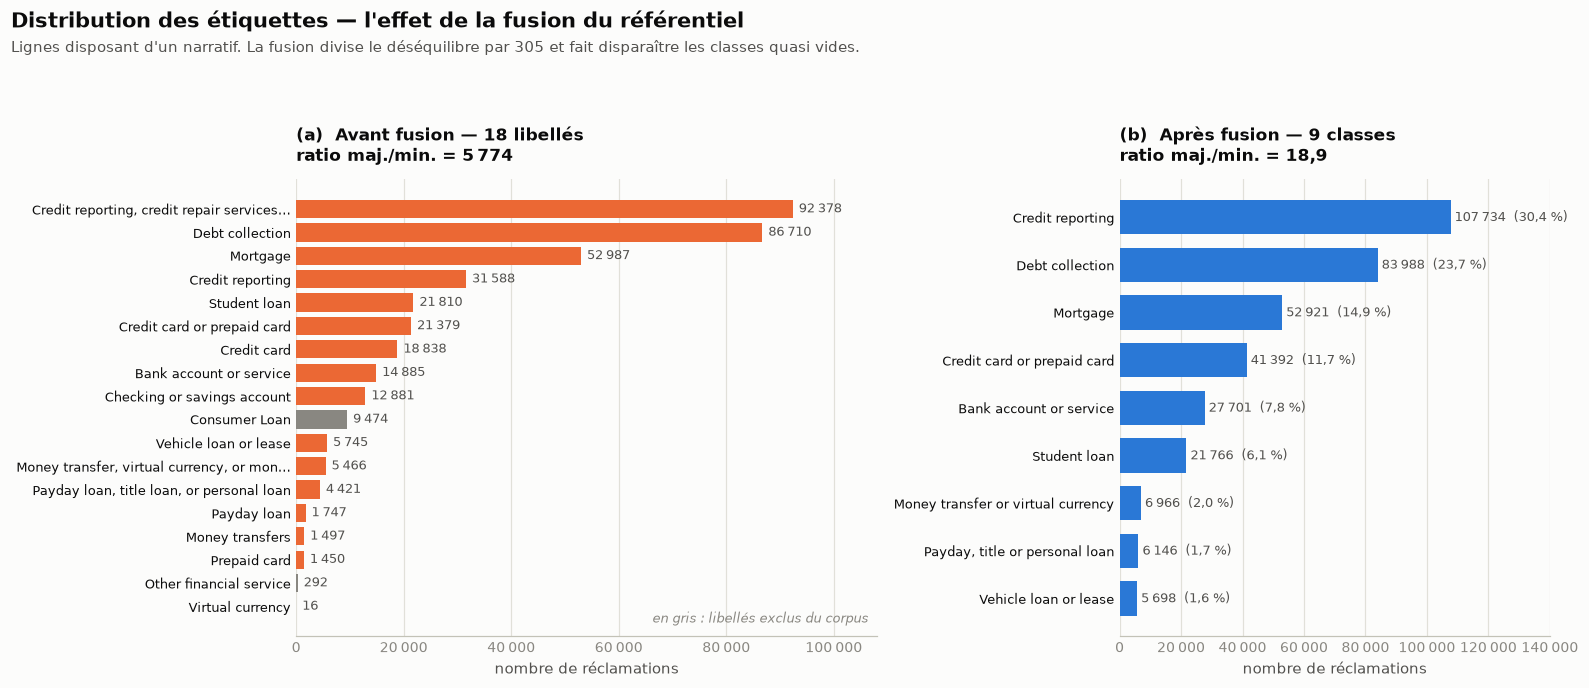

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 6),
                               gridspec_kw={"width_ratios": [1.35, 1]})

# --- (a) 18 libelles bruts --------------------------------------------------
a = avant.sort_values()
exclus = set(cfg.EXCLUDED_LABELS)
couleurs = [ATTENUE if lib in exclus else ORANGE for lib in a.index]
ax1.barh(range(len(a)), a.values, color=couleurs, height=0.78, zorder=3)
for i, v in enumerate(a.values):
    ax1.text(v + a.max() * 0.012, i, fr(v), va="center", fontsize=8.3, color=ENCRE2)
ax1.set_yticks(range(len(a)),
               [lib if len(lib) <= 42 else lib[:40] + "…" for lib in a.index],
               fontsize=8.3, color=ENCRE)
ax1.set_xlim(0, a.max() * 1.17)
ax1.set_xticks(ax1.get_xticks(), [fr(t) for t in ax1.get_xticks()])
ax1.set_xlim(0, a.max() * 1.17)
ax1.set_xlabel("nombre de réclamations")
epure(ax1)
ax1.set_title(f"(a)  Avant fusion — {len(a)} libellés\n"
              f"ratio maj./min. = {fr(ratio_avant)}",
              loc="left", color=ENCRE, fontweight="bold", pad=12)
ax1.text(0.985, 0.03, "en gris : libellés exclus du corpus", transform=ax1.transAxes,
         ha="right", fontsize=8.3, color=ATTENUE, style="italic")

# --- (b) 9 classes fusionnees ----------------------------------------------
b = apres.sort_values()
ax2.barh(range(len(b)), b.values, color=BLEU, height=0.72, zorder=3)
for i, v in enumerate(b.values):
    ax2.text(v + b.max() * 0.012, i, f"{fr(v)}  ({fr(v / b.sum() * 100, 1)} %)",
             va="center", fontsize=8.6, color=ENCRE2)
ax2.set_yticks(range(len(b)), b.index, fontsize=8.8, color=ENCRE)
ax2.set_xlim(0, b.max() * 1.30)
ax2.set_xticks(ax2.get_xticks(), [fr(t) for t in ax2.get_xticks()])
ax2.set_xlim(0, b.max() * 1.30)
ax2.set_xlabel("nombre de réclamations")
epure(ax2)
ax2.set_title(f"(b)  Après fusion — {len(b)} classes\n"
              f"ratio maj./min. = {fr(ratio_apres, 1)}",
              loc="left", color=ENCRE, fontweight="bold", pad=12)

fig.suptitle("Distribution des étiquettes — l'effet de la fusion du référentiel",
             x=0.007, ha="left", fontsize=13.5, fontweight="bold", color=ENCRE, y=1.035)
fig.text(0.007, 0.972,
         "Lignes disposant d'un narratif. La fusion divise le déséquilibre par "
         f"{fr(ratio_avant / ratio_apres)} et fait disparaître les classes quasi vides.",
         ha="left", fontsize=9.5, color=ENCRE2)
fig.tight_layout(rect=[0, 0, 1, 0.945])

chemin = cfg.FIGURES_DIR / "label_distribution.png"
fig.savefig(chemin)
print("figure enregistree :", chemin.relative_to(RACINE))
plt.show()

### Commentaire

**Avant fusion, le ratio majoritaire/minoritaire atteint 5 774** : 92 378 réclamations
pour `Credit reporting, credit repair services…` contre **16** pour
`Virtual currency`. Une classe à 16 exemples est ininterprétable — son F1 serait
gouverné par le hasard, et comme le F1-macro pèse toutes les classes à égalité, ce
hasard contaminerait la métrique principale du projet.

**Après fusion, le ratio tombe à 18,9.** Le déséquilibre est divisé par 305. Il reste
réel — `Credit reporting` pèse 30,4 % du corpus, `Vehicle loan or lease` 1,6 % — mais
il est désormais **modéré et traitable** : pondération `class_weight='balanced'` côté
ML, et F1-macro comme métrique de décision.

C'est le gain principal de la fusion, et il ne tient pas seulement à la lisibilité :
il rend le problème statistiquement mesurable.

## 5. Distribution des longueurs de texte

### Pourquoi cette section existe

Trois décisions en dépendent :

1. **Le seuil de longueur minimale** — faut-il écarter les textes trop courts, et à
   partir de quand ?
2. **Le coût et la latence du LLM**, qui sont proportionnels au nombre de tokens, donc
   à la longueur.
3. **La faisabilité même de la tâche** : si les réclamations étaient des messages de
   quelques mots, aucune approche ne fonctionnerait.

In [15]:
n_car = propre[cfg.TEXT_COL].str.len()
n_mot = propre[cfg.TEXT_COL].str.split().str.len()

quantiles = [0, .05, .25, .50, .75, .95, .99, 1.0]
longueurs = pd.DataFrame({
    "caracteres": [n_car.quantile(q) for q in quantiles],
    "mots": [n_mot.quantile(q) for q in quantiles],
}, index=[f"p{int(q * 100)}" for q in quantiles]).astype(int)
longueurs.loc["moyenne"] = [int(n_car.mean()), int(n_mot.mean())]
# Approximation usuelle pour un texte anglais et un tokenizer BPE (cf. §10 : hypothese).
longueurs["tokens (~mots x 1,3)"] = (longueurs["mots"] * 1.3).astype(int)
longueurs

,caracteres,mots,"tokens (~mots x 1,3)"
p0,20,1,1
p5,144,26,33
p25,410,75,97
p50,769,141,183
p75,1393,255,331
p95,3267,595,773
p99,5114,929,1207
p100,31634,6314,8208
moyenne,1107,202,262


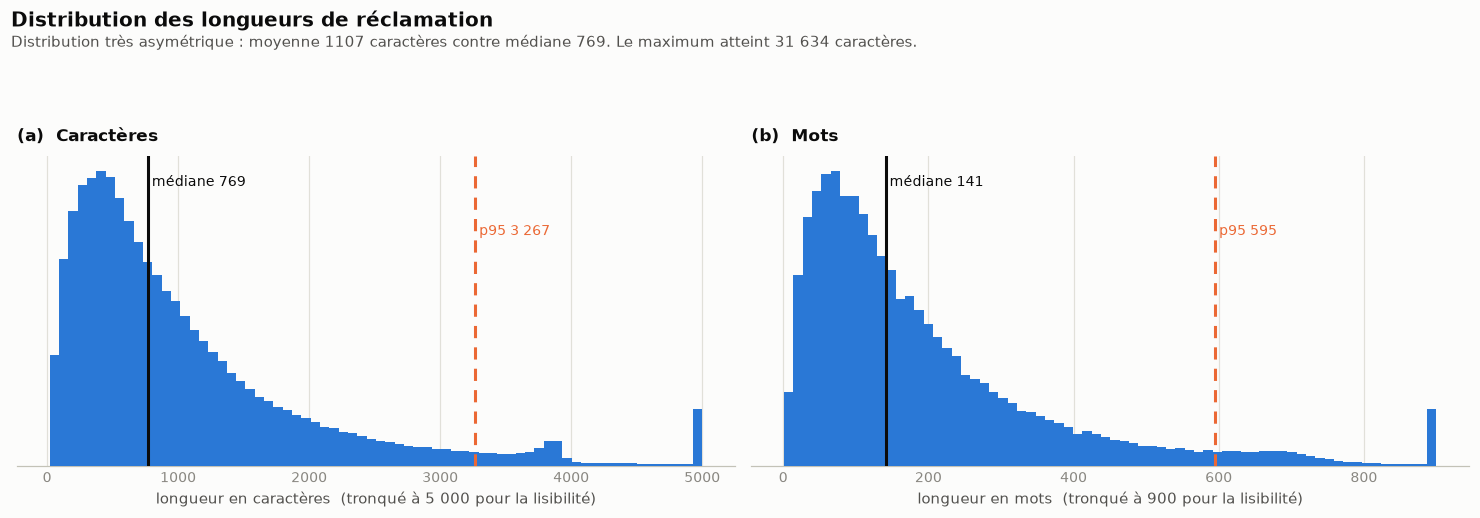

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.4))

for ax, serie, unite, coupe in [(ax1, n_car, "caractères", 5000),
                                (ax2, n_mot, "mots", 900)]:
    ax.hist(serie.clip(upper=coupe), bins=70, color=BLEU, zorder=3)
    ax.axvline(serie.median(), color=ENCRE, lw=2, zorder=5)
    ax.axvline(serie.quantile(.95), color=ORANGE, lw=2, ls=(0, (4, 3)), zorder=5)
    ax.set_xlabel(f"longueur en {unite}  (tronqué à {coupe:,} pour la lisibilité)"
                  .replace(",", " "))
    ax.set_yticks([])
    epure(ax)
    ax.text(serie.median(), ax.get_ylim()[1] * 0.94, f" médiane {serie.median():,.0f}"
            .replace(",", " "), fontsize=9, color=ENCRE, va="top")
    ax.text(serie.quantile(.95), ax.get_ylim()[1] * 0.78,
            f" p95 {serie.quantile(.95):,.0f}".replace(",", " "),
            fontsize=9, color=ORANGE, va="top")

ax1.set_title("(a)  Caractères", loc="left", color=ENCRE, fontweight="bold", pad=10)
ax2.set_title("(b)  Mots", loc="left", color=ENCRE, fontweight="bold", pad=10)
fig.suptitle("Distribution des longueurs de réclamation",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=ENCRE, y=1.06)
fig.text(0.007, 0.985,
         f"Distribution très asymétrique : moyenne {n_car.mean():.0f} caractères contre "
         f"médiane {n_car.median():.0f}. Le maximum atteint {n_car.max():,} caractères."
         .replace(",", " "),
         ha="left", fontsize=9.5, color=ENCRE2)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [17]:
seuil = cfg.MIN_TEXT_LENGTH
print(f"seuil retenu MIN_TEXT_LENGTH = {seuil} caracteres")
print(f"  supprime a l'etape 6 : {rapport['6_texte_trop_court']['supprimees']} lignes "
      f"({rapport['6_texte_trop_court']['supprimees'] / 383_564 * 100:.3f} % des "
      f"lignes exploitables)")
print(f"\ntextes restants de moins de 50 caracteres  : {int((n_car < 50).sum()):,}")
print(f"textes restants de moins de 100 caracteres : {int((n_car < 100).sum()):,}")
print(f"textes de plus de 5 000 caracteres         : {int((n_car > 5000).sum()):,}")
print(f"\nlongueur maximale : {n_car.max():,} caracteres "
      f"({n_mot.max():,} mots, soit environ {n_mot.max() * 1.3:,.0f} tokens)")

seuil retenu MIN_TEXT_LENGTH = 20 caracteres
  supprime a l'etape 6 : 147 lignes (0.038 % des lignes exploitables)

textes restants de moins de 50 caracteres  : 1,625
textes restants de moins de 100 caracteres : 8,927
textes de plus de 5 000 caracteres         : 3,800

longueur maximale : 31,634 caracteres (6,314 mots, soit environ 8,208 tokens)


### Lecture

*(Les chiffres ci-dessous portent sur le corpus **nettoyé**. Ils diffèrent légèrement de
ceux du diagnostic, calculés avant dédoublonnage : les courriers types dupliqués étant
plutôt courts, leur retrait relève un peu la médiane.)*

**Le corpus est substantiel.** La médiane est à **769 caractères / 141 mots**, et même
le 5ᵉ percentile atteint **144 caractères** : **95 % des réclamations ont assez de
matière pour être classées**. Ce n'est pas un corpus de messages courts — la tâche est
faisable.

**La distribution est fortement asymétrique à droite** : moyenne **1 107** caractères
contre médiane **769**, maximum à **31 634 caractères** (6 314 mots, ~8 200 tokens).
Les textes extrêmes sont des dépôts pseudo-juridiques, pas des réclamations ordinaires.

**Le seuil de 20 caractères est un bon arbitrage** : il ne coûte que 147 lignes
(0,04 %) et élimine des textes structurellement non classables — « Account is fraud »
ou « Needs to be removed » pourraient relever de n'importe laquelle des neuf classes.
Le p5 étant à 144 caractères, le seuil est très loin de la masse de la distribution :
aucun risque de couper du signal utile.

**Conséquence pour l'étape 2** : la queue de distribution justifie une **troncature à
1 000 mots au moment de construire le prompt**. Elle ne toucherait que 0,82 % des
textes et ne réduirait le coût moyen que de 2 %, mais elle **plafonne le pire cas à
~1 300 tokens au lieu de 8 200**. C'est une protection contre la variance de coût et de
latence, pas une optimisation. Cette troncature n'est **pas** appliquée dans
`data_prep` : les fichiers produits contiennent le texte intégral, pour ne pas
handicaper le modèle ML qui n'en a aucun besoin.

## 6. Exemples concrets de réclamations par classe

### Pourquoi lire les données

Les statistiques ne disent pas si la tâche est *faisable*. Lire des exemples réels
permet de juger si les frontières entre classes sont nettes — et c'est ce jugement qui
détermine si un **plafond de performance** est à attendre, quelle que soit l'approche
retenue.

On regarde les trois classes les plus grosses et les trois plus petites.

In [18]:
rng = np.random.default_rng(cfg.RANDOM_SEED)
effectifs = propre[cfg.LABEL_COL].value_counts()


def montre(classes, titre):
    print("=" * 100)
    print(titre)
    print("=" * 100)
    for classe in classes:
        sous = propre[(propre[cfg.LABEL_COL] == classe)
                      & propre[cfg.TEXT_COL].str.len().between(280, 620)]
        print(f"\n### {classe}   (n = {effectifs[classe]:,})")
        for texte in sous[cfg.TEXT_COL].iloc[rng.choice(len(sous), 2, replace=False)]:
            print(f"  • {texte[:420]}…")


montre(list(effectifs.index[:3]), "LES 3 CLASSES LES PLUS GROSSES")
print()
montre(list(effectifs.index[-3:]), "LES 3 CLASSES LES PLUS PETITES")

LES 3 CLASSES LES PLUS GROSSES

### Credit reporting   (n = 107,734)
  • Always apply any freezes and unfreeze to report online. Attempted to temporarily lift credit freeze online for a certain amount of days and received error message. Attempted again TWICE and payment processed and charges fee TWICE but freeze not lifted without written letter that I have since submitted. No fee should be charged if freeze was not lifted and there is no reason why my account should require request in wr…
  • XXXX account was transferred to XXXX XXXX XXXX XXXX XXXX XXXX card couldnt settle the account cause it was transferred to XXXX XXXX. XXXX XXXX took the payment and settled on this account. Was being reported as paid charge off on XX/XX/18 now on XX/XX/18 saying charge off again. Please update as paid charge off settled in full XXXX bal. XXXX # XXXX…

### Debt collection   (n = 83,988)
  • XXXX XXXX XXXX , XXXX is attempting to collect a debt does not belong to me. They continue to send me informa


### Mortgage   (n = 52,921)
  • The prior mortgage servicer canceled an existing home owners insurance policy and force placed insurance. this increased the escrow portion of my mortgage payment and has since resulted in a large escrow shortage. Also the current servicer has approved a modification that is unaffordable. The offer is XXXX months at 4.625 % deferred XXXX , UPB of XXXX p & i of XXXX escorw of XXXX with XXXX down…
  • Reverse mortgage tv advertising offers a free kit that explains options. Free, just call this number. I called and it was Quicken Loans. The person called me back from a non-toll-free number and continued to ask more and more probing questions " need to know this before I can send you the kit '' that included request for next of kin contact and for my social security number. This is verging on criminal. I never did g…

LES 3 CLASSES LES PLUS PETITES

### Money transfer or virtual currency   (n = 6,966)
  • I believe paypal is scamming me. A few months ago I 

### Le masquage `XXXX`

Les extraits ci-dessus le montrent : **85 % des textes contiennent des séquences
`XXXX`**, appliquées par le CFPB avant publication. Elles remplacent indistinctement
noms de personnes, noms d'entreprises, dates, adresses et montants.

Nous ne les retirons **pas** :

- côté **TF-IDF**, le mécanisme de l'IDF les neutralise automatiquement — un token
  présent dans 85 % des documents a un IDF proche de zéro (≈ 0,16). Un `max_df=0.9`
  suffit comme filet de sécurité ;
- côté **LLM**, le texte brut doit rester intact ; l'instruction système mentionnera le
  masquage pour que le modèle sache quoi en faire.

Le vrai coût du masquage est ailleurs : il **détruit les entités nommées**. Le modèle ne
peut pas apprendre que « Navient » signale un prêt étudiant ni qu'« Equifax » signale un
litige de dossier de crédit. Il doit s'appuyer sur le vocabulaire générique
(`forbearance`, `escrow`, `repossess`). **Ce handicap frappe les deux approches pour la
même raison — ce n'est donc pas un facteur discriminant dans la recommandation
finale**, et il faut le dire explicitement, car c'est un biais d'analyse tentant.

In [19]:
# Quantification du masquage et des autres artefacts.
txt = propre[cfg.TEXT_COL]
artefacts = pd.Series({
    "masquage XX+": txt.str.contains(r"XX+", regex=True).mean(),
    "date masquee XX/XX": txt.str.contains(r"XX/XX", regex=True).mean(),
    "montant masque {$...}": txt.str.contains(r"\{\$", regex=True).mean(),
    "URL": txt.str.contains(r"https?://|www\.", regex=True).mean(),
    "caracteres non-ASCII": txt.str.contains(r"[^\x00-\x7F]", regex=True).mean(),
}) * 100
pd.DataFrame({"% des lignes": artefacts.round(2)})

,% des lignes
masquage XX+,86.26
date masquee XX/XX,40.04
montant masque {$...},31.95
URL,0.44
caracteres non-ASCII,0.04


**URL et caractères non latins sont négligeables** (< 0,5 %) : aucun nettoyage
spécifique ne se justifie, le rapport bénéfice/complexité serait mauvais. Le corpus est
monolingue anglais.

### Jugement sur la séparabilité

Les exemples révèlent une difficulté de fond. **L'étiquette du CFPB désigne le *produit
financier* concerné, alors que le texte décrit souvent le *préjudice ressenti*** — qui
est presque toujours « ça abîme mon dossier de crédit ». Une plainte sur un prêt auto
est fréquemment rédigée comme un litige de signalement.

Le diagnostic complet ([`reports/diagnostic.md`](../reports/diagnostic.md), §C) mesure
ce recouvrement : **35,8 % des réclamations `Debt collection` et 26,7 % des
`Vehicle loan or lease` mentionnent explicitement le dossier de crédit**. Les paires les
plus exposées à la confusion sont :

| Paire | Mécanisme |
|---|---|
| `Credit reporting` ↔ `Debt collection` | une dette recouvrée est *aussi* signalée aux bureaux de crédit — **54 % du corpus** |
| `Credit card or prepaid card` ↔ `Bank account or service` | carte de débit, découvert, prépayé adossé à un compte : périmètres réellement chevauchants |
| `Money transfer` ↔ `Bank account or service` | un virement passe par un compte |

**Un plafond de performance est donc à attendre pour les deux approches.** Il faut
l'annoncer *avant* de présenter les résultats, sinon les scores se lisent comme un
échec. Sa quantification — et ce qu'on ne peut pas quantifier — fait l'objet du §10.

## 7. Découpage train / test et vérification de la stratification

### Pourquoi un découpage aléatoire stratifié

**Stratifié** parce que le corpus est déséquilibré (ratio 18,9). Un tirage simple
ferait varier la proportion des classes rares entre train et test, ce qui rendrait les
scores instables et non comparables d'une exécution à l'autre.

**Aléatoire et non temporel**, pour la raison établie au §3 : `Vehicle loan or lease`
n'existe qu'à partir d'avril 2017 et se retrouverait entièrement d'un seul côté d'une
coupure chronologique.

Un découpage temporel serait pourtant le plus réaliste vis-à-vis de la production
(on entraîne sur le passé, on prédit le futur). C'est un compromis assumé, imposé par
la bascule de référentiel — et il doit être mentionné dans les limites.

> Les fichiers ont déjà été produits par `python -m src.data_prep`. Le notebook les
> **relit** au lieu de refaire le découpage : c'est ce qui garantit qu'il commente
> exactement les données que consommeront les étapes 2 et 3.

In [20]:
import json

train, test = dp.load_split()
meta = json.loads(cfg.SPLIT_METADATA_FILE.read_text(encoding="utf-8"))

print(f"train : {len(train):,} lignes")
print(f"test  : {len(test):,} lignes")
print(f"total : {len(train) + len(test):,}  "
      f"(corpus nettoye : {rapport['resume']['lignes_finales']:,})")
print(f"\nseed = {meta['random_seed']} | test_size = {meta['test_size']} | "
      f"sample_fraction = {meta['sample_fraction']}")
print("\nempreintes sha256 (l'identite des fichiers est verifiable) :")
for nom, info in meta["fichiers"].items():
    print(f"  {nom:12s} {info['lignes_de_donnees']:>7,} lignes  {info['sha256'][:16]}…")

train : 283,449 lignes
test  : 70,863 lignes
total : 354,312  (corpus nettoye : 354,312)

seed = 42 | test_size = 0.2 | sample_fraction = 1.0

empreintes sha256 (l'identite des fichiers est verifiable) :
  train        283,449 lignes  eeaf757019362752…
  test          70,863 lignes  f4d9c0c4beae54ba…
  eval_sample    2,000 lignes  8cfc0205ec70549e…


In [21]:
# La stratification est-elle respectee ? Ecart en points de % par classe.
dp.verifie_stratification(meta)

,corpus_pct,train_pct,test_pct,ecart_train,ecart_test,ok
Credit reporting,30.407,30.407,30.407,0.000,0.000,True
Debt collection,23.705,23.704,23.705,-0.001,0.000,True
Mortgage,14.936,14.936,14.936,0.000,0.000,True
Credit card or prepaid card,11.682,11.682,11.683,0.000,0.001,True
Bank account or service,7.818,7.818,7.818,0.000,0.000,True
Student loan,6.143,6.143,6.143,0.000,0.000,True
Money transfer or virtual currency,1.966,1.966,1.966,0.000,0.000,True
"Payday, title or personal loan",1.735,1.735,1.734,0.000,-0.001,True
Vehicle loan or lease,1.608,1.608,1.609,0.000,0.001,True


In [22]:
# Aucun texte ne doit se retrouver des deux cotes : c'est ce que garantit le
# dedoublonnage effectue AVANT le decoupage (cf. section 2).
fuite = set(train[cfg.TEXT_COL]) & set(test[cfg.TEXT_COL])
print(f"textes presents a la fois dans train et test : {len(fuite)}")
print(f"identifiants communs                         : "
      f"{len(set(train[cfg.ID_COL]) & set(test[cfg.ID_COL]))}")
print(f"doublons de texte au sein du train           : "
      f"{int(train[cfg.TEXT_COL].duplicated().sum())}")

textes presents a la fois dans train et test : 0
identifiants communs                         : 0
doublons de texte au sein du train           : 0


### Résultat

L'écart de composition entre le corpus, le train et le test est d'au plus **0,001 point
de pourcentage** sur les neuf classes : la stratification est exacte.

**Aucun texte n'est partagé entre train et test.** C'est la vérification la plus
importante de cette section — sans le dédoublonnage préalable, les 19 160 doublons
auraient produit une fuite massive et un score de test trompeur.

Les empreintes `sha256` permettent de vérifier que le pipeline est **idempotent** :
relancer `python -m src.data_prep` reproduit des fichiers strictement identiques.

## 8. L'échantillon d'évaluation du LLM

### Le problème à résoudre

Évaluer le LLM sur les **70 863 lignes du test complet** est impossible en pratique :
à environ une seconde par appel et sous contrainte de limitation de débit, cela
représente **une vingtaine d'heures**. Le coût, lui, ne serait pas un obstacle (~3,80 $) —
c'est la **latence** qui contraint, et c'est un point à formuler correctement dans la
recommandation.

Il faut donc évaluer sur un échantillon. Mais lequel ?

### Pourquoi pas un simple échantillon proportionnel

Un échantillon proportionnel de 2 000 lignes ne contiendrait que **32 réclamations
`Vehicle loan or lease`**. Or le F1-**macro**, notre métrique de décision, pèse cette
classe à égalité avec `Credit reporting` (608 lignes). Une poignée d'erreurs sur 32
observations ferait bouger la métrique principale du projet.

Une simulation Monte-Carlo (2 000 réplicats, 4 scénarios de matrice de confusion,
[`reports/h1_sampling_simulation.md`](../reports/h1_sampling_simulation.md)) a comparé
six stratégies. Résultat, **à coût LLM identique (2 000 appels)** :

| Stratégie | RMSE du F1-macro | RMSE du F1 de la classe la plus faible | Écart minimal détectable |
|---|---:|---:|---:|
| Proportionnel, n = 2 000 | 0,0153 | 0,0627 | **4,0 points** |
| **Plancher 50/classe + pondération, n = 2 000** | **0,0123** | **0,0482** | **3,1 points** |

La stratégie retenue — dite **B3** — tire **au minimum 50 items par classe**, le solde
étant réparti proportionnellement. Elle réduit le RMSE de 20 %, celui de la classe la
plus faible de 23 %, et **fait passer l'écart minimal détectable entre les deux
approches de 4,0 à 3,1 points de F1-macro**.

C'est ce dernier chiffre qui a décidé : la mission consiste précisément à **départager
le LLM et le ML**. Avec un échantillon proportionnel, un écart réel de 3,5 points serait
indétectable. Le classement des deux stratégies est stable sur les quatre scénarios
testés.

In [23]:
# `load_eval_sample()` retourne un TUPLE : c'est un garde-fou, voir plus bas.
eval_df, poids = dp.load_eval_sample()

info = meta["echantillon_evaluation"]
alloc = pd.DataFrame(info["par_classe"]).T
alloc.columns = ["N_test", "n_tiré", "taux de sondage (‰)", "poids w_c"]
alloc.loc["TOTAL"] = [alloc.N_test.sum(), alloc["n_tiré"].sum(), np.nan, np.nan]
alloc

,N_test,n_tiré,taux de sondage (‰),poids w_c
Credit reporting,21547.0,521.0,24.18,41.3570
Debt collection,16798.0,417.0,24.82,40.2830
Mortgage,10584.0,282.0,26.64,37.5319
Credit card or prepaid card,8279.0,231.0,27.90,35.8398
Bank account or service,5540.0,171.0,30.87,32.3977
Student loan,4353.0,145.0,33.31,30.0207
Money transfer or virtual currency,1393.0,81.0,58.15,17.1975
"Payday, title or personal loan",1229.0,77.0,62.65,15.9610
Vehicle loan or lease,1140.0,75.0,65.79,15.2000
TOTAL,70863.0,2000.0,NaN,NaN


In [24]:
prop = (test[cfg.LABEL_COL].value_counts(normalize=True)
        .reindex(cfg.CLASS_ORDER) * cfg.LLM_EVAL_SAMPLE_SIZE).round().astype(int)
comparaison = pd.DataFrame({
    "proportionnel (rejeté)": prop,
    "B3 plancher 50 (retenu)": eval_df[cfg.LABEL_COL].value_counts().reindex(cfg.CLASS_ORDER),
})
comparaison["gain"] = comparaison.iloc[:, 1] - comparaison.iloc[:, 0]
print(comparaison.to_string())
print(f"\nsomme des poids : {poids.sum():,.0f}  =  taille du test : {len(test):,}")
print("-> les poids reconstituent exactement la population de reference")

                                    proportionnel (rejeté)  B3 plancher 50 (retenu)  gain
label                                                                                    
Credit reporting                                       608                      521   -87
Debt collection                                        474                      417   -57
Mortgage                                               299                      282   -17
Credit card or prepaid card                            234                      231    -3
Bank account or service                                156                      171    15
Student loan                                           123                      145    22
Money transfer or virtual currency                      39                       81    42
Payday, title or personal loan                          35                       77    42
Vehicle loan or lease                                   32                       75    43

somme des

### ⚠️ La contrepartie : la pondération est obligatoire

En sur-échantillonnant volontairement les classes rares, **l'échantillon B3 n'est plus
représentatif de la distribution du test**. Les poids de Horvitz-Thompson
(`w_c = N_c / n_c`) le ramènent à la population de référence.

Sans eux, les métriques sont fausses — et pas d'un cheveu :

| Métrique | Biais si l'on oublie les poids |
|---|---:|
| F1-macro | **+0,022** |
| Précision de `Vehicle loan or lease` | **+0,29** |
| Précision de `Credit reporting` | **−0,082** |

Ces valeurs sont **mesurées** sur 2 000 réplicats, pas estimées. Un biais de +0,022 sur
le F1-macro est du même ordre de grandeur que l'écart que l'on cherche à mesurer entre
les deux approches : l'oublier ne dégraderait pas la précision de la mesure, il
**inverserait potentiellement la conclusion**.

Cinq garde-fous ont donc été implémentés pour rendre l'oubli difficile. La cellule
suivante en démontre deux.

In [25]:
# Garde-fou 1 : `sample_weight` n'a PAS de valeur par defaut -> TypeError immediat.
try:
    mt.evaluate(eval_df[cfg.LABEL_COL], eval_df[cfg.LABEL_COL])
except TypeError as e:
    print("garde-fou 1 (TypeError) :", e)

# Garde-fou 2 : passer None alors que la source porte des poids -> ValueError.
try:
    mt.evaluate(eval_df[cfg.LABEL_COL], eval_df[cfg.LABEL_COL],
                sample_weight=None, source=eval_df)
except ValueError as e:
    print("\ngarde-fou 2 (ValueError) :", str(e).splitlines()[0])

print("\nles trois autres garde-fous :")
print("  3. load_eval_sample() retourne un tuple (df, weights), jamais un DataFrame seul")
print("  4. il leve si SAMPLE_FRACTION < 1.0 : aucune campagne d'API sur un corpus de dev")
print("  5. le CSV porte une ligne d'avertissement en tete : un pd.read_csv() nu")
print("     produit un DataFrame inexploitable (KeyError au premier acces)")

garde-fou 1 (TypeError) : evaluate() missing 1 required keyword-only argument: 'sample_weight'

garde-fou 2 (ValueError) : Le DataFrame source contient la colonne 'sampling_weight' mais aucun `sample_weight` n'a ete fourni.

les trois autres garde-fous :
  3. load_eval_sample() retourne un tuple (df, weights), jamais un DataFrame seul
  4. il leve si SAMPLE_FRACTION < 1.0 : aucune campagne d'API sur un corpus de dev
  5. le CSV porte une ligne d'avertissement en tete : un pd.read_csv() nu
     produit un DataFrame inexploitable (KeyError au premier acces)


### Deux tableaux de résultats, pas un seul

À l'étape 4, la comparaison produira **deux tableaux distincts**, et les fusionner
serait exactement l'erreur que le garde-fou 2 empêche :

| Tableau | Population | Pondéré | Ce qu'il montre |
|---|---|---|---|
| **1** | les 2 000 lignes de `test_sample_2000.csv` | oui | LLM vs ML — **seule comparaison valide** |
| **2** | les 70 863 lignes de `test.csv` | non | ML seul — **l'apport du volume d'entraînement** |

Le second tableau porte un argument central de la recommandation : le modèle ML exploite
**283 449 exemples annotés**, là où le LLM en exploite une poignée en few-shot. C'est
son avantage structurel, et il ne se voit que sur le test complet.

## 9. Choix des métriques

### 9.1 Métrique principale : le F1-macro

Le corpus présente un **ratio majoritaire/minoritaire de 18,9**, mesuré au §4. Ce seul
chiffre disqualifie l'*accuracy* comme métrique de décision. La démonstration est plus
convaincante qu'un argument : on évalue un « modèle » qui prédit systématiquement la
classe majoritaire.

In [26]:
# Modele temoin : predit toujours la classe majoritaire. Il ne comprend rien.
y_vrai = eval_df[cfg.LABEL_COL]
y_majoritaire = pd.Series([cfg.CLASS_ORDER[0]] * len(eval_df), index=eval_df.index)

temoin = mt.evaluate(y_vrai, y_majoritaire, sample_weight=poids,
                     source=eval_df, with_ci=False)

print(f"MODELE TEMOIN — predit toujours « {cfg.CLASS_ORDER[0]} »")
print(f"  accuracy  = {temoin['accuracy']:.4f}   <-- semble presque acceptable")
print(f"  F1-macro  = {temoin['f1_macro']:.4f}   <-- revele l'imposture")
print(f"  rappel macro    = {temoin['recall_macro']:.4f}")
print(f"  precision macro = {temoin['precision_macro']:.4f}")
print(f"\n8 classes sur 9 ont un F1 de 0 : le modele ne les predit jamais.")

MODELE TEMOIN — predit toujours « Credit reporting »
  accuracy  = 0.3041   <-- semble presque acceptable
  F1-macro  = 0.0518   <-- revele l'imposture
  rappel macro    = 0.1111
  precision macro = 0.0338

8 classes sur 9 ont un F1 de 0 : le modele ne les predit jamais.


**Le modèle témoin obtient 30 % d'accuracy sans rien comprendre**, mais un F1-macro de
0,05. L'écart entre les deux chiffres est exactement le piège que le F1-macro évite.

Trois raisons de le retenir comme métrique principale :

1. **Il pèse les neuf classes à égalité.** C'est ce qui correspond au besoin métier :
   une réclamation mal routée coûte la même chose au client, qu'elle porte sur un prêt
   immobilier ou sur un virement. Rien ne justifie de valoriser davantage les catégories
   fréquentes.
2. **Il combine précision et rappel.** Sur-prédire une classe rare pour gonfler son
   rappel dégrade sa précision, et le F1 le sanctionne.
3. **Il est sensible là où le problème est difficile** — précisément sur les classes
   rares, dont les frontières sont les plus floues (§6).

Métriques secondaires conservées : l'accuracy et le F1-weighted (parlants pour le
client, qui raisonne en volume traité), ainsi que la **précision et le rappel par
classe**, indispensables à l'analyse d'erreurs de l'étape 3.

⚠️ **Le F1-macro global pourrait ne pas départager les deux approches.** La simulation
du §8 a produit deux profils d'erreur volontairement très différents classe par classe,
et leurs F1-macro ne diffèrent que de **0,004**. Deux modèles au comportement
radicalement distinct peuvent avoir un F1-macro quasi identique. C'est pourquoi
`compare_results()` affiche systématiquement le **F1 par classe** à côté de l'agrégat.

In [27]:
# Tout resultat affiche porte son intervalle de confiance, obtenu par bootstrap
# INTRA-STRATES : le reechantillonnage se fait avec remise a l'interieur de chaque
# classe, en conservant l'effectif de chacune. Un bootstrap uniforme ferait varier
# le nombre d'items des classes rares d'un tirage a l'autre, ce qui ajouterait une
# variance absente du plan de sondage reel et sous-estimerait la precision.
rng = np.random.default_rng(cfg.RANDOM_SEED)
y_simule = np.where(rng.random(len(y_vrai)) < 0.72, y_vrai,
                    rng.choice(cfg.CLASS_ORDER, len(y_vrai)))

stratifie = mt.evaluate(y_vrai, y_simule, sample_weight=poids, source=eval_df,
                        strata="auto", n_boot=400)
uniforme = mt.evaluate(y_vrai, y_simule, sample_weight=poids, source=eval_df,
                       strata=None, n_boot=400)

for nom, res in [("intra-strates (retenu)", stratifie), ("uniforme", uniforme)]:
    ic = res["f1_macro_ci"]
    print(f"{nom:24s} F1-macro = {ic['valeur']:.4f}  "
          f"IC 95 % = [{ic['bas']:.4f} ; {ic['haut']:.4f}]  "
          f"largeur = {ic['haut'] - ic['bas']:.4f}   (strata : {res['bootstrap_strata']})")

print("\nATTENTION : y_simule est un jeu de predictions SYNTHETIQUE, destine a")
print("illustrer le comportement des metriques. Ce n'est la performance d'aucun modele.")

intra-strates (retenu)   F1-macro = 0.6392  IC 95 % = [0.6184 ; 0.6593]  largeur = 0.0409   (strata : y_true (auto))
uniforme                 F1-macro = 0.6392  IC 95 % = [0.6158 ; 0.6654]  largeur = 0.0496   (strata : aucune)

ATTENTION : y_simule est un jeu de predictions SYNTHETIQUE, destine a
illustrer le comportement des metriques. Ce n'est la performance d'aucun modele.


### 9.2 Latence : le p95, pas la moyenne

Le second critère de la recommandation est la latence — c'est elle, et non le coût, qui
contraint réellement l'approche LLM (§8).

**Nous retenons le 95ᵉ percentile plutôt que la moyenne.** Les latences d'API suivent
une distribution à queue lourde : une majorité d'appels rapides et une minorité très
lents. La moyenne est écrasée par la masse des appels rapides et **masque exactement ce
que l'utilisateur perçoit comme « le service rame »**. Le p95 répond à la question qui
compte pour le client : *combien de temps attendent les 5 % les moins bien servis ?*

La cellule suivante illustre l'écart sur une distribution synthétique à queue lourde.

In [28]:
# ILLUSTRATION SYNTHETIQUE — aucune mesure reelle n'est disponible avant l'etape 2.
# Loi log-normale, forme typique d'une latence d'API.
rng = np.random.default_rng(cfg.RANDOM_SEED)
latences_simulees = rng.lognormal(mean=-0.15, sigma=0.62, size=2000)

stats = mt.latency_stats(latences_simulees)
for cle, valeur in stats.items():
    if cle != "latence_n":
        print(f"  {cle:22s} = {valeur:6.2f} s")

ecart = stats["latence_p95_s"] / stats["latence_moyenne_s"]
print(f"\nle p95 vaut {ecart:.1f} x la moyenne : annoncer la moyenne au client")
print("reviendrait a sous-estimer l'attente reelle d'un facteur du meme ordre.")
print("\n(distribution synthetique, a seule fin d'illustration)")

  latence_moyenne_s      =   1.01 s
  latence_p50_s          =   0.85 s
  latence_p95_s          =   2.29 s
  latence_max_s          =   6.18 s

le p95 vaut 2.3 x la moyenne : annoncer la moyenne au client
reviendrait a sous-estimer l'attente reelle d'un facteur du meme ordre.

(distribution synthetique, a seule fin d'illustration)


In [29]:
# Le chronometre de metrics.py mesure CHAQUE appel individuellement, jamais un
# temps total divise par n : une moyenne masquerait la dispersion, or c'est
# precisement la dispersion qui interesse le client.
chrono = mt.Timer()
for _ in range(200):
    with chrono:
        sum(range(1500))

print(f"appels chronometres : {chrono.n}")
print("statistiques :", {k: round(v, 6) for k, v in chrono.summary().items()})
print("\nEn cas d'appels parallelises a l'etape 2, la latence enregistree reste celle")
print("de l'APPEL UNITAIRE : c'est la latence percue par l'utilisateur final, a ne pas")
print("confondre avec le debit global du lot.")

appels chronometres : 200
statistiques : {'latence_n': 200, 'latence_moyenne_s': 9e-06, 'latence_p50_s': 9e-06, 'latence_p95_s': 9e-06, 'latence_max_s': 1.7e-05}

En cas d'appels parallelises a l'etape 2, la latence enregistree reste celle
de l'APPEL UNITAIRE : c'est la latence percue par l'utilisateur final, a ne pas
confondre avec le debit global du lot.


### 9.3 Coût d'exploitation

Le coût ne se résume pas à un chiffre : il dépend du **modèle retenu** et de
l'activation du **cache de préfixe**. `metrics.compare_models_cost()` produit le
tableau complet — c'est le support de la restitution sur le coût d'exploitation.

Les tarifs ont été relevés le **11/08/2026** sur les pages publiques des fournisseurs
(sources listées dans [`reports/limites.md`](../reports/limites.md), §4.1). Ils sont
**volatils** : OpenAI a baissé `gpt-5.6-luna` de 80 % le 30/07, DeepSeek a annoncé une
hausse le 06/08.

In [30]:
# Tableau comparatif sur la campagne d'evaluation de l'etape 2 (2 000 appels).
tableau_cout = mt.compare_models_cost(cfg.LLM_EVAL_SAMPLE_SIZE)
tableau_cout

,fournisseur,$/M entrée,$/M sortie,coût 2000 préd. ($),avec cache ($),économie cache (%),$/an sans cache,$/an avec cache,note
ministral-3b,Mistral,0.1,0.1,0.1014,0.056,44.7,18.51,10.23,
deepseek-v4-flash,DeepSeek,0.14,0.28,0.1448,0.0756,47.8,26.42,13.8,
mistral-small-4,Mistral,0.15,0.6,0.1611,0.0931,42.2,29.4,16.98,
gpt-5.6-luna,OpenAI,0.2,1.2,0.2228,0.1321,40.7,40.66,24.1,
mistral-large-3,Mistral,0.5,1.5,0.527,0.3002,43.0,96.18,54.79,
gemini-3.5-flash,Google,0.75,4.5,0.8355,0.8355,0.0,152.48,152.48,
claude-haiku-4.5,Anthropic,1.0,5.0,1.094,0.6404,41.5,199.66,116.87,
claude-sonnet-5,Anthropic,3.0,15.0,3.282,1.9212,41.5,598.97,350.62,'claude-sonnet-5' : le tarif d'introduction (2.0/10.0 $ par M de token
claude-opus-5,Anthropic,5.0,25.0,5.47,3.202,41.5,998.27,584.37,
gpt-5.6-sol,OpenAI,5.0,30.0,5.57,3.302,40.7,1016.52,602.62,


In [31]:
# Trois regimes de cache. Le parametre `cached_prefix_tokens` de estimate_cost
# recoit le nombre MOYEN de tokens caches par appel, soit
#     prefixe x couverture x taux d'activation.
obs = cfg.CACHE_MESURE[cfg.DEFAULT_MODEL]
pref = cfg.CACHED_PREFIX_TOKENS_PAR_MODELE[cfg.DEFAULT_MODEL]

defaut  = mt.estimate_cost(1000)
theorique = mt.estimate_cost(1000, cached_prefix_tokens=pref)
mesure  = mt.estimate_cost(
    1000, cached_prefix_tokens=pref * obs["couverture_prefixe"] * obs["taux_activation"])
campagne = mt.estimate_cost(
    cfg.LLM_EVAL_SAMPLE_SIZE,
    cached_prefix_tokens=pref * obs["couverture_prefixe"] * obs["taux_activation"])
complet = mt.estimate_cost(
    len(test),
    cached_prefix_tokens=pref * obs["couverture_prefixe"] * obs["taux_activation"])

print(f"MODELE PAR DEFAUT : {defaut['model']} ({defaut['fournisseur']}) — "
      f"{defaut['input_per_1m']} / {defaut['output_per_1m']} $ par M de tokens")
print(f"tokens MESURES le {cfg.AVG_COMPLAINT_TOKENS_MESURE_LE} : "
      f"{cfg.AVG_COMPLAINT_TOKENS} pour le texte + {pref} de prefixe\n")

for nom, r in [("sans cache", defaut),
               ("cache MESURE (regime etabli)", mesure),
               ("cache THEORIQUE (borne)", theorique)]:
    eco = (1 - r["cout_total_usd"] / defaut["cout_total_usd"]) * 100
    print(f"  1 000 predictions, {nom:30s} : {r['cout_total_usd']:.4f} $"
          f"   -> {r['cout_annuel_usd']:>6.1f} $ / an"
          + (f"   ({eco:.1f} %)" if eco else ""))

print(f"\n  campagne d'evaluation ({cfg.LLM_EVAL_SAMPLE_SIZE:,} appels) : "
      f"{campagne['cout_total_usd']:.3f} $")
print(f"  test complet ({len(test):,} appels)          : "
      f"{complet['cout_total_usd']:.2f} $")

fourchette = tableau_cout["$/an sans cache"]
print(f"\nfourchette du catalogue, sans cache : {fourchette.min():.0f} $ "
      f"({fourchette.idxmin()}) a {fourchette.max():,.0f} $ ({fourchette.idxmax()}) par an"
      .replace(",", " "))
print(f"volumes de tokens mesures pour : "
      f"{', '.join(sorted(cfg.FOURNISSEURS_TOKENS_MESURES))} — "
      f"HYPOTHESE pour les autres fournisseurs (tokenizers differents)")
print(f"tarifs verifies le {defaut['tarif_verifie_le']}")
for a in campagne["avertissements"]:
    print("  avertissement :", a)

MODELE PAR DEFAUT : mistral-small-4 (Mistral) — 0.15 / 0.6 $ par M de tokens
tokens MESURES le 2026-08-19 : 245 pour le texte + 252 de prefixe

  1 000 predictions, sans cache                     : 0.0805 $   ->   29.4 $ / an
  1 000 predictions, cache MESURE (regime etabli)   : 0.0509 $   ->   18.6 $ / an   (36.8 %)
  1 000 predictions, cache THEORIQUE (borne)        : 0.0465 $   ->   17.0 $ / an   (42.2 %)

  campagne d'evaluation (2,000 appels) : 0.102 $
  test complet (70,863 appels)          : 3.61 $

fourchette du catalogue  sans cache : 19 $ (ministral-3b) a 1 017 $ (gpt-5.6-sol) par an
volumes de tokens mesures pour : Mistral — HYPOTHESE pour les autres fournisseurs (tokenizers differents)
tarifs verifies le 2026-08-19


### Trois lectures du tableau

**1. Le coût n'est pas le facteur discriminant.** Du moins cher au plus cher, la
projection annuelle pour 1 000 réclamations quotidiennes va de **19 $** à
**1 017 $**. Deux ordres de grandeur — et pourtant, même le
plus cher reste négligeable devant le coût du traitement manuel qu'il remplace.
**Conséquence : le modèle peut être choisi sur sa qualité et ses contraintes de
conformité, pas sur son prix.**

**2. Le cache de préfixe pèse plus lourd que le choix du modèle — mais moins que prévu.**
Le préfixe constant (instruction + liste des 9 étiquettes) **mesuré à 252 tokens**
représente environ la moitié des 497 tokens d'entrée par appel.

Ce point a été **mesuré à l'étape 2 sur 200 appels réels**, et la mesure corrige une
projection initiale trop optimiste :

| régime | économie | ce que c'est |
|---|---|---|
| démarrage à froid (20 premiers appels) | **21%** | cache encore vide |
| **régime établi** (mesuré) | **37%** | ce qu'obtient une campagne longue |
| borne théorique | 42% | plafond, jamais atteint |

Deux effets, tous deux invisibles avant mesure. La **couverture est plafonnée** : le
cache ne sert jamais que 224 tokens sur les 252 du préfixe, une quantification
structurelle qui ne bouge pas. Et l'**activation dépend du réchauffement** : 55%
sur les 20 premiers appels, 98% ensuite.

**3. Ce qui contraint réellement, c'est la latence.** Évaluer sur les 70 863 lignes du
test coûterait quelques dollars — mais prendrait une vingtaine d'heures. C'est cela qui
justifie l'échantillon de 2 000, et c'est ainsi qu'il faut le formuler au client : un
argument de temps de traitement, pas de budget.

### ⚠️ Trois précautions

- **Les volumes de tokens ne sont mesurés que pour Mistral.** Les tokenizers d'Anthropic,
  OpenAI, Google et DeepSeek diffèrent : pour ces fournisseurs, les colonnes du tableau
  restent des **hypothèses**. Un flag global unique ferait passer 8 modèles sur 10 pour
  mesurés.
- **La colonne « avec cache » du tableau des 10 modèles est la borne théorique**, donc
  optimiste. Seul Mistral a été mesuré. Le levier `prompt_cache_key`, qui rapprocherait
  le régime réel de la borne, est documenté dans
  [`reports/leviers_optimisation.md`](../reports/leviers_optimisation.md) — il a été
  volontairement écarté de l'évaluation, qui doit mesurer le comportement par défaut.
- `claude-sonnet-5` bénéficie d'un **tarif d'introduction expirant le 31/08/2026** ;
  le tarif standard (+50 %) s'applique au 01/09. `estimate_cost()` bascule
  automatiquement et lève un avertissement passé cette date.

Le détail — sources, volatilité, tier gratuit, API Batch, argument RGPD — est en §4 de
[`reports/limites.md`](../reports/limites.md).

## 10. Limites et précautions d'interprétation

Synthèse courte — l'analyse complète, avec toutes les mesures, est dans
[`reports/limites.md`](../reports/limites.md).

Quatre limites, dont **deux ne sont pas corrigeables** : ce sont des propriétés du jeu
de données, pas des défauts du pipeline. Elles sont donc quantifiées plutôt que
supposées.

### 1. Portée — un biais de périmètre, pas un biais de performance

**Le narratif est strictement équivalent au consentement** : zéro ligne a un texte sans
consentement à publication, sur 1,28 million de lignes. Cinq canaux de dépôt sur six
(téléphone, courrier, fax, e-mail, transmission inter-agences) ne produisent **jamais**
de texte — **26,3 % du flux est hors périmètre par nature**.

La solution couvre donc **29,9 % du flux historique et environ 46 % du flux courant**.

La distinction essentielle à retenir :

> Le corpus d'entraînement et le flux réellement traité en production sont **la même
> population** — les réclamations web consenties — puisque seules celles-ci ont un texte
> à classer. C'est une **réduction de périmètre**, pas une dégradation de performance
> sur le périmètre couvert.

*Formulation client* : « La solution automatise la part du flux qui arrive sous forme de
texte exploitable, soit ~46 % des réclamations reçues aujourd'hui. Le reste continue de
relever du traitement manuel, non par limite du modèle mais parce qu'il n'y a rien à
lire. »

### 2. Plafond de performance — borné, mais non mesurable

**Ce qui est prouvé** : au moins **208 lignes (0,056 %)** sont *nécessairement* mal
classées, car des textes identiques portent des étiquettes différentes. Une accuracy de
99,94 % est mathématiquement inatteignable. En tolérant les quasi-doublons (200 premiers
caractères), la borne monte à 655 lignes (**0,175 %**).

**Ce qui est fortement indiqué** : le plafond réel est bien supérieur. **22,8 % des
modèles de courrier type** sont classés dans plusieurs catégories, et la borne triple
dès qu'on assouplit légèrement la définition de « même texte ».

**Ce qui n'est pas mesurable** : sa valeur. Il faudrait une double annotation
indépendante, qui n'existe pas — le fichier CFPB ne porte qu'une étiquette par
réclamation. **Aucune extrapolation n'est faite** : les textes répétés sont précisément
les courriers types les plus génériques, donc les plus ambigus ; ils ne constituent pas
un échantillon représentatif du corpus.

🔜 **Action étape 3** : analyse d'erreurs croisée LLM/ML. Si les deux approches se
trompent sur les **mêmes textes**, aux **mêmes endroits**, c'est la preuve empirique que
la limite est dans les données. C'est la seule mesure honnête du plafond disponible dans
ce projet, et elle ne coûte rien de plus.

### 3. Un seul tirage d'échantillon

`test_sample_2000.csv` est un tirage unique (seed 42). La simulation portait sur la
*distribution* des tirages possibles ; elle ne dit pas si celui-ci est favorable ou
défavorable — ni s'il l'est de la même façon pour les deux approches.

🔜 **Action étape 2** : `data_prep.construit_echantillon_alternatif(seed)` produit un
second échantillon avec la même allocation et un tirage indépendant (recouvrement
mesuré : 2,3 %). Réévaluer dessus une fois le prompt figé coûte ~0,11 $ et fournit une
preuve empirique de stabilité **plus forte que l'IC bootstrap** — l'IC mesure la
variabilité *interne* à un échantillon, le second tirage mesure la variabilité *entre*
échantillons.

### 4. Hypothèses de coût provisoires et tarifs volatils

Aucune valeur de coût n'est mesurée sur le système réel. `AVG_COMPLAINT_TOKENS = 257`
provient de l'approximation « mots × 1,3 », non vérifiée sur le tokenizer de Mistral —
et **85 % des textes contiennent du masquage `XXXX`, qui se tokenise mal**. Le facteur
réel pourrait être sensiblement supérieur.

Les **tarifs** sont tout aussi provisoires : relevés le 11/08/2026, ils ont bougé deux
fois en six semaines (OpenAI −80 % sur `gpt-5.6-luna` le 30/07, hausse DeepSeek annoncée
le 06/08 sans date ni montant). `claude-sonnet-5` change mécaniquement le 01/09/2026.

Ces constantes sont regroupées dans `config.py` sous un bandeau explicite ;
`estimate_cost()` retourne un flag `hypotheses`, le tarif appliqué et la liste des
avertissements, pour qu'aucun chiffre ne soit présenté sans son statut.

Trois points opérationnels détaillés dans le rapport, à ne pas manquer à l'étape 2 :
le **tier gratuit Mistral** couvrirait toute l'évaluation mais les données peuvent
servir à l'entraînement sauf opt-out — inacceptable sur des réclamations clients
réelles ; l'**API Batch** (−50 %) est incompatible avec la mesure de latence ; et
l'argument **RGPD** (Mistral est européen, ZenAssist traite des données européennes) est
un critère non statistique qui doit figurer dans la recommandation finale.

🔜 **Action étape 2** : le champ `usage` des réponses de l'API donne les comptes de
tokens réels — les substituer, revérifier les dix tarifs, recalculer. *Ce qui ne
changera pas* : la conclusion — l'écart entre le modèle le moins cher et le plus cher
couvre déjà deux ordres de grandeur sans qu'aucun ne soit significatif. *Ce qui
changera* : les chiffres affichés, qui doivent être justes.

## Récapitulatif

| Décision | Valeur | Fondement |
|---|---|---|
| Colonne texte / étiquette | `Consumer Claim` / `Tag` | seules colonnes non issues du post-traitement |
| Périmètre | 383 564 lignes avec narratif | les 70 % restants n'ont rien à classer |
| Fusion du référentiel | 16 → **9 classes** | bascule CFPB du 21-24 avril 2017, mesurée |
| Exclusions | `Consumer Loan`, `Other financial service` | correspondance non injective ; effectif négligeable |
| `MIN_TEXT_LENGTH` | 20 caractères | coûte 0,04 %, le p5 est à 144 caractères |
| `MIN_SAMPLES_PER_CLASS` | 1 000 | garde-fou ; ne supprime rien (min = 5 698) |
| Corpus final | **354 312 lignes**, ratio 18,9 | contre 5 774 avant fusion |
| Découpage | 80/20 stratifié, seed 42 | temporel impossible : `Vehicle loan` post-2017 |
| Échantillon LLM | 2 000, plancher 50/classe, **pondéré** | écart détectable 3,1 pts contre 4,0 |
| Métrique principale | **F1-macro** | ratio 18,9 ; témoin majoritaire à 0,05 |
| Latence | **p95** | la moyenne masque la queue de distribution |

### Ce qui suit

- **Étape 2 — LLM** : construction du prompt, campagne sur les 2 000 lignes,
  vérification sur le second tirage, mesure des tokens réels.
- **Étape 3 — ML classique** : pipeline TF-IDF + classifieur linéaire sur les 283 449
  lignes d'entraînement, évalué **deux fois** (sur les 2 000 pondérées pour la
  comparaison, sur le test complet pour montrer l'apport du volume), puis analyse
  d'erreurs croisée.
- **Étape 4 — recommandation** : diaporama de 5 à 15 diapositives destiné à l'équipe
  ZenAssist — un product owner, deux développeurs, **aucune compétence IA en interne**.
  Il doit établir cinq choses : la **justification des métriques** retenues, les
  **performances** des deux approches, leurs **temps de réponse rapportés à
  l'expérience utilisateur visée**, un **plan de mise en production de chacune avec son
  temps de mise en place** et ses coûts — implémentation et exploitation distingués —
  et une **recommandation explicite et justifiée**.

---

*Étape 1 — analyse exploratoire et préparation. Pipeline reproductible :
`python -m src.data_prep`.*